In [7]:
"""
Last.fm devulve stats.listeners y stats.playcount por artista
El problema es la ley de las potencias, el 1% de los artistas va a concentrar el 90% de las escuchas

Para que el motor funcione necesita un coeficiente que escale del 0 al 1 o del 0 al 100
Entonces, toca un analisis con un par de datos:
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

plt.style.use('ggplot')

In [8]:
N = 6000

raw_listener = (np.random.pareto(1.2, N) + 1) * 50_000 # 50_000 escala los resultados haciendo que el minimo sea de 50000
"""
    El m +1 transforma el valor minimo a 1 por una cuestion de simplicidad matematica.    

    La distribucion de pareto simula una distribucion de ley de potencias
la distribucion de los datoa tambien es de cola larga. La mayoria de los artistas
tienen pocos oyentes, mientras que unos pocos artistas tienen millones.
"""
raw_playcount = raw_listener * (np.random.uniform(20, 500, N)) # Se generan 'N' valores aleatorios entre [20, 500]
"""
    Aca se asume que el total de reproducciones es proporcional al numero de oyentes.
    En los valores reales obtenidos a traves de la API, estos valores explicarian que tan 
'repetitiva' es la audiencia de cada artista.
"""

"\n    Aca se asume que el total de reproducciones es proporcional al numero de oyentes.\n    En los valores reales obtenidos a traves de la API, estos valores explicarian que tan \n'repetitiva' es la audiencia de cada artista.\n"

In [9]:
df = pd.DataFrame({
    'artista': [f"Artista {i}" for i in range(N)],
    'oyentes': raw_listener.astype(int),
    'reproducciones': raw_playcount.astype(int)
})

total = df['oyentes'].sum()
mejores_50 = df.nlargest(50, "oyentes")["oyentes"].sum()

print(f"El top 1% de los artistas concentra el {round((mejores_50/total)*100, 2)}% de los oyentes\n")

# Para ver un poco mejor los valores voy a traer 5 bandas reales, deberia cambiar el valor
"""
    Los artistas que voy a usar son:
    1_ACDC              46.400.000 - 25.600.000.000
    2_Queen             54.600.000 - 28.900.000.000
    3_Rediohead         52.600.000 - 15.900.000.000
    4_The Beatles       35.400.000 - 25.600.000.000
    5_Guns N' Roses   38.400.000 - 13.300.000.000  
"""

raw_listener[:5] = [46.4e6, 54.6e6, 52.6e6, 35.4e6, 38.4e6]
raw_playcount[:5] = [25.6e9, 28.9e9, 15.9e9, 25.6e9, 13.3e9]

df = pd.DataFrame({
    'artista': [f"Artista {i}" for i in range(N)],
    'oyentes': raw_listener.astype(int),
    'reproducciones': raw_playcount.astype(int)
})

df.loc[0, 'artista'] = 'ACDC'
df.loc[1, 'artista'] = 'Queen'
df.loc[2, 'artista'] = 'Radiohead'
df.loc[3, 'artista'] = 'The Beatles'
df.loc[4, 'artista'] = "Guns N' Roses"

total = df['oyentes'].sum()
mejores_50 = df.nlargest(50, "oyentes")["oyentes"].sum()

print("\nNuevos valores:")
print(f"El top 1% de los artistas concentra el {round((mejores_50/total)*100, 2)}% de los oyentes")
# Son mucho mejores valores, pero ya son suficientes para hacer la estimacion del coeficiente.

El top 1% de los artistas concentra el 64.34% de los oyentes


Nuevos valores:
El top 1% de los artistas concentra el 66.64% de los oyentes


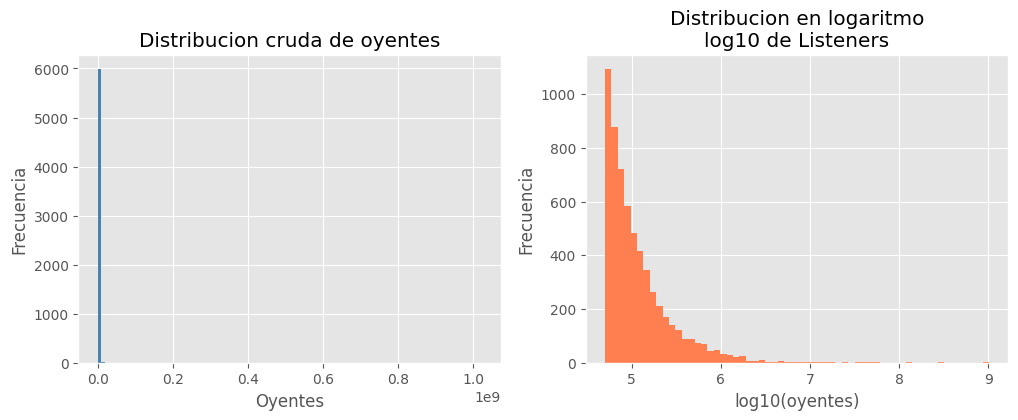

[46400000 54600000 52600000 ...   140784   119300   294917]


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['oyentes'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribucion cruda de oyentes')
axes[0].set_xlabel('Oyentes') 
axes[0].set_ylabel('Frecuencia')


axes[1].hist(np.log10(df['oyentes'] + 1), bins=60, color='coral', edgecolor='none')
axes[1].set_title('Distribucion en logaritmo\nlog10 de Listeners')
axes[1].set_xlabel('log10(oyentes)')
axes[1].set_ylabel('Frecuencia')

plt.show()
print(df['oyentes'].values)


In [11]:
"""
    Para tener un coeficiente se tienen que conseguir valores del 0 al 1 normalizando los valores.
    La formula estandar del normalizado es: 
        Xnormalizada = (x - x.min())/(x.max() - x.min())
"""


def minmax_lineal(x):
    # Normalizacion lineal en minimo y maximo, son los valores bases
    return (x - x.min()) / (x.max() - x.min())


def log_minmax(x, base=10):
    # Normalizacion logaritmica
    # Se comprime la diferencia entre valores chicos y grandes
    log_x = np.log(x + 1) / np.log(base) # La suma de (x + 1) es para evitar el logaritmo de 0
    return (log_x - log_x.min()) / (log_x.max() - log_x.min())


def percentil_rank(x):
    '''
        Para entender esta normalizacion se puede hacer un ejemplo con el siguiente array: [10, 20, 20 30]
    donde se asignarian los rangos 1, 2, 3, y 4, pero como hay dos 20's estos reciben el promedio 
    de sus rangos, 2 y 3, como resultado de los rangos se tendria esto [1, 2.5, 2.5, 4].
    '''
    # Normalizacion por posicion de percentil en el corpus
    return rankdata(x, method='average') / len(x) # Asigna un rango a cada elemento x
    # se divide por el numero total de elementos para obtener la normalizacion.


def log_sigmoide(x, k=5):
    # Normalizacion sigmoidea, tiene mas control sobre la curva.
    log_x = np.log(x + 1) # Transformacion logaritmica, (x + 1) evita errores de logaritmo de 0.
    mu = np.median(log_x) # No usa una media como promedio, usa una mediana porque cambia menos a con
    # respecto a valores extremos.
    sigma = log_x.std() # Desviacion estandar de los datos logaritmicos
    z = k * (log_x - mu) / sigma # Basicamente, ahora los datos tienen centro en 0 y 
    # dispercion pareciada a la desviacion estandar. El factor k es un coeficiente  de suavizado o pendiente.
    return 1 / (1 + np.exp(-z))

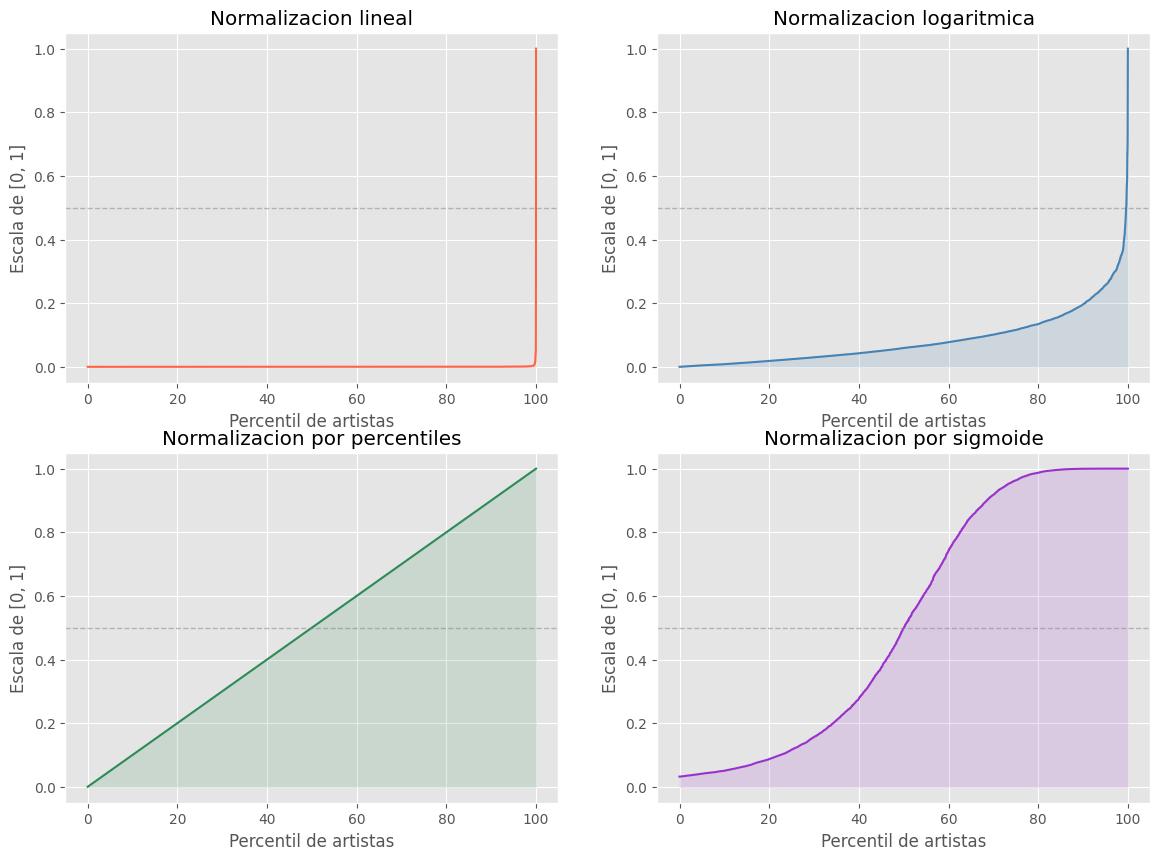

In [12]:
df['idx_lineal'] = minmax_lineal(df['oyentes'].values)
df['idx_logartimico'] = log_minmax(df['oyentes'].values)
df['idx_percentil'] = percentil_rank(df['oyentes'].values)
df['idx_sigmoide'] = log_sigmoide(df['oyentes'].values) 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

#Normalizacion lineal:
lineal = df.sort_values('oyentes')['idx_lineal'].values
axes[0].plot(np.linspace(0, 100, len(lineal)), lineal, color= 'tomato')
axes[0].set_title('Normalizacion lineal')
axes[0].set_xlabel('Percentil de artistas')
axes[0].set_ylabel('Escala de [0, 1]')
axes[0].axhline(0.5, color= 'gray', lw= 1, ls= '--', alpha= 0.5)
axes[0].fill_between(np.linspace(0, 100, len(lineal)), lineal, alpha= 0.15, color= 'tomato')

#Normalizacion logaritmica:
logaritmica = df.sort_values('oyentes')['idx_logartimico'].values
axes[1].plot(np.linspace(0, 100, len(logaritmica)), logaritmica, color= 'steelblue')
axes[1].set_title('Normalizacion logaritmica')
axes[1].set_xlabel('Percentil de artistas')
axes[1].set_ylabel('Escala de [0, 1]')
axes[1].axhline(0.5, color= 'gray', lw= 1, ls= '--', alpha= 0.5)
axes[1].fill_between(np.linspace(0, 100, len(logaritmica)), logaritmica, alpha= 0.15, color= 'steelblue')

#Normalizacion por percentil:
percentil = df.sort_values('oyentes')['idx_percentil'].values
axes[2].plot(np.linspace(0, 100, len(percentil)), percentil, color= 'seagreen')
axes[2].set_title('Normalizacion por percentiles')
axes[2].set_xlabel('Percentil de artistas')
axes[2].set_ylabel('Escala de [0, 1]')
axes[2].axhline(0.5, color= 'gray', lw= 1, ls= '--', alpha= 0.5)
axes[2].fill_between(np.linspace(0, 100, len(percentil)), percentil, alpha= 0.15, color= 'seagreen')

#Normalizacion de sigmoide:
sigmoide = df.sort_values('oyentes')['idx_sigmoide'].values
axes[3].plot(np.linspace(0, 100, len(sigmoide)), sigmoide, color= 'darkorchid')
axes[3].set_title('Normalizacion por sigmoide')
axes[3].set_xlabel('Percentil de artistas')
axes[3].set_ylabel('Escala de [0, 1]')
axes[3].axhline(0.5, color= 'gray', lw= 1, ls= '--', alpha= 0.5)
axes[3].fill_between(np.linspace(0, 100, len(sigmoide)), sigmoide, alpha= 0.15, color= 'darkorchid')

plt.show()

In [13]:
""" 
    Otra cosa que hay que hacer es pasar la escala [0, 1] a [1, 2], ya que en el peor de los casos, el cual es que el artista 
no tenga escuchas, el coeficiente no disminuye las ganancias minimas y en el mejor de los casos, duplica el valor. 
"""

# coeficiente = (1 + normalizacion)

"""
    PERO TODO ESTO TIENE UN ERROR:
        Primero: trabaje con datos inventados y una pequeñisima parte de datos reales.

        Segundo: para hacer andar estos normalizadores necesitaria conocer en todo momento el numero
    real de oyentes de todos los artistas y como estos numeros los saco de la API RESTful de Last.fm (gracias Last.fm)
    no puedo pasarme de chistoso pidiendo datos o me banean.

    Para solucionar el primer problema lo tengo facil, tendria que filtrar la categoria, como esto es para el Poncho
directamente podria señir todo a regeton, folclore, chacarera y algun que otro rock argentino, quizas, que se escucha en el Poncho ?

    El segundo es el problema grande, pero se me ocurren dos opciones:

        Primera: El logaritmo solo necesita un valor minimo y otro maximo, entonces transformo todo a 
    normalizacion por logaritmo y toda esa normalizacion la paso por sigmoide como que si fuera un percentil,
    entonces solo tendria que darle un valor minimo y otro maximo y consigo un percentil medio real (mentira, no es muy real
    pero tambien tengo una vida fuera de la computadora)

        Segunda: Yo la llamo "No tengo vida fuera de la computadora", Last.fm me va a banear si me paso de vivo en 
    peticiones por segundo, pero por lo que vi tienen un maximo de 5 peticiones por segundo y no tienen limite diario, 
    entonces si hago una peticion por segundo la safo. Entonces, que tal si consigo la forma de traer muchos datos solo de 
    folclore, regueton, chacarera y ese algun que otro rock nacional para tener valores mas alineados con el consumo del Poncho ????
        Asi tendria como una base de datos para estimar bien el coeficiente y tendria datos realmente representativos. 


    Bien, segun Chat GPT: Lo que sí se puede inferir de las programaciones oficiales de los últimos años es que la enorme mayoría
de la oferta artística se concentra en estos géneros: folklore, cuarteto, cumbia y, más recientemente, música urbana. Rock, pop, tango 
y reggae aparecen, pero con mucha menor presencia.

Entonces las categorias musicales y su orden de importancia para el Poncho y segun ChatGPT (soy EL peor cientifico de datos del planeta):
    1 Folklore (vengo escribiendolo con c, asi lo voy a dejar)
    2 Cuarteto
    3 Cumbia
    4 Urbano/Trap (a los pedazos)
    5 Rock
    6 Otros (Estos ya no los voy a utilizar)

    Mientras que los artistas mas importantes de estas categorias a nivel nacional son (de vuelta por ChatGPT):
"""
Floklore = ['Abel Pintos', 'Soledad Pastorutti', 'Jorge Rojas', 'Oscar Esperanza Palavecino', 
    'Luciano Pereyra', 'Peteco Carabajal', 'Raly Barrionuevo', 'Lázaro Caballero', 'Sergio Galleguillo',
    'LosNocherosOficial', 'lostekis', 'Destino San Javier', 'Los Manseros Santiagueños']

Cuarteto = ['La Mona Jiménez', 'Ulises Bueno', "La K'onga", "Q' Lokura", 'DesaKTa2', 'Damián Córdoba', 'Luck Ra',]


Cumbia = ['Ke Personajes', 'Karina', 'El Polaco', 'La Delio Valdez', 'Los Palmeras', 'Los Totora']


UrbanoTrap = ['Cazzu', 'Emanero', 'Duki', 'Nicki Nicole', 'Wos', 'Tiago PZK']


Rock = ['Charly García', 'Luis Alberto Spinetta', 'Fito Páez', 'Andrés Calamaro', 'Gustavo Cerati', 'Soda Stereo',
    'Patricio Rey y sus Redonditos de Ricota', 'Los Piojos', 'Babasónicos']



"""
    Uhh, last.fm es anglosajona, no tiene nada de folklore jajajajajajajaja
    Bueno, cambio de rumbo: Youtube, pero viendolo ahora creo que es hasta incluso mejor, lo explico:
    Basicamente esta API me da 10mil unidades de cuota gratis al dia, donde buscar el canal de un artista cuesta 100 unidades
y buscar cuantas visitas tiene cuesta 1 unidad. Si busco 41 artistas al dia, estaria gastando 100 por canal y 1 por sus numeros que son
4141 unidades al dia, o sea que con las listas de arriba me sobra para poder hacer las peticiones para cargar los eventos.
"""
artistas = Floklore + Cuarteto + Cumbia + UrbanoTrap + Rock
print(len(artistas))

41


In [ ]:
import os
import django

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'TicketAPI_Poncho.settings')
django.setup()

from apps.core.services import obtener_vistas_youtube
import time

# Se viene loco
datos = []
for artista in artistas:
    vistas = obtener_vistas_youtube(artista)

    if vistas is not None:
        datos.append({'artista': artista, 'reproducciones': vistas})
        print('coso')
    else: 
        print(f"no hay nada del pibe este: {artista}")
    time.sleep(0.5) # No me banees youtube 

print(datos)

coso
[{'artista': 'lostekis', 'reproducciones': 121721128}]


In [4]:
import django
import os

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'TicketAPI_Poncho.settings')
django.setup()

from apps.core.services import obtener_vistas_youtube
import time

datos = []
vistas = obtener_vistas_youtube('CARAFEAOFICIA')

if vistas is not None:
    datos.append({'artista': 'CARAFEAOFICIA', 'reproducciones': vistas})
    print('coso')
else:  print('No coso')

print(datos)

coso
[{'artista': 'CARAFEAOFICIA', 'reproducciones': 35470523}]


In [14]:
coso = [{'artista': 'Soledad Pastorutti', 'reproducciones': 700111900}, {'artista': 'Jorge Rojas', 'reproducciones': 323683131}, 
        {'artista': 'Luciano Pereyra', 'reproducciones': 3191195181}, {'artista': 'Peteco Carabajal', 'reproducciones': 18181269}, 
        {'artista': 'Raly Barrionuevo', 'reproducciones': 23828684}, {'artista': 'Sergio Galleguillo', 'reproducciones': 39703701}, 
        {'artista': 'Ulises Bueno', 'reproducciones': 313230814}, {'artista': 'DesaKTa2', 'reproducciones': 196277988}, 
        {'artista': 'Damián Córdoba', 'reproducciones': 455895884}, {'artista': 'Luck Ra', 'reproducciones': 2228730954}, 
        {'artista': 'Ke Personajes', 'reproducciones': 3284242937}, {'artista': 'Karina', 'reproducciones': 3420336300}, 
        {'artista': 'El Polaco', 'reproducciones': 126669}, {'artista': 'Los Palmeras', 'reproducciones': 5463}, 
        {'artista': 'Cazzu', 'reproducciones': 835603902}, {'artista': 'Emanero', 'reproducciones': 1361386651}, 
        {'artista': 'Duki', 'reproducciones': 4927952121}, {'artista': 'Nicki Nicole', 'reproducciones': 2388476311}, 
        {'artista': 'Wos', 'reproducciones': 1601834972}, {'artista': 'Tiago PZK', 'reproducciones': 3620876620}, 
        {'artista': 'Charly García', 'reproducciones': 236405328}, {'artista': 'Andrés Calamaro', 'reproducciones': 621235042}, 
        {'artista': 'Gustavo Cerati', 'reproducciones': 422798510}, {'artista': 'Soda Stereo', 'reproducciones': 1129916281}, 
        {'artista': 'Babasónicos', 'reproducciones': 362314829}, {'artista': 'LosNocherosOficial', 'reproducciones': 408951298},
        {'artista': 'lostekis', 'reproducciones': 121721128}]

print(len(coso))
"""
    Bueno, anda. Tendria que encontrar los nombres exactos de los canales de los artistas que faltan
pero ya es un comienzo y ya podria calcular coeficientes.

"""
reproducciones = []
nombres = []
for i in coso:
    reproducciones.append(i['reproducciones'])
    nombres.append(i['artista'])

print(len(nombres), nombres)
# Tengo 27 datos de los 35 artistas que habia conseguido antes. Voy a ver de cuales faltan los datos para 
#buscar sus nombres en youtube.
print(len(artistas), len(nombres))
distintos = list(set(artistas) - set(nombres)) # Una diferencia de conjuntos
print( len(distintos) ,distintos)
#Bueno, ahora con estos datos puedo volver a buscar en la API de youtube los valores faltantes


27
27 ['Soledad Pastorutti', 'Jorge Rojas', 'Luciano Pereyra', 'Peteco Carabajal', 'Raly Barrionuevo', 'Sergio Galleguillo', 'Ulises Bueno', 'DesaKTa2', 'Damián Córdoba', 'Luck Ra', 'Ke Personajes', 'Karina', 'El Polaco', 'Los Palmeras', 'Cazzu', 'Emanero', 'Duki', 'Nicki Nicole', 'Wos', 'Tiago PZK', 'Charly García', 'Andrés Calamaro', 'Gustavo Cerati', 'Soda Stereo', 'Babasónicos', 'LosNocherosOficial', 'lostekis']
41 27
14 ['Abel Pintos', 'Patricio Rey y sus Redonditos de Ricota', 'Destino San Javier', "La K'onga", 'Fito Páez', 'Lázaro Caballero', 'La Delio Valdez', 'Luis Alberto Spinetta', 'Oscar Esperanza Palavecino', 'Los Piojos', 'La Mona Jiménez', 'Los Totora', 'Los Manseros Santiagueños', "Q' Lokura"]


In [15]:
lst = ['destinosanjavier', 'SpinettaOficial', 'PatricioReyYSusRedonditos', 'LosManserosSantiagueños', 'AbelPintos', 'LaMonaJiménez-m1y', 
    'LaKonga', 'OficialLosPiojos', 'FitoPaezOficial', 'qlokuraok', 'ChaquenoPalavecinoOficial', 'LosTotoraOficial', 'LaDelioValdez', 
    'lazarocaballerooficial']
# Todo lo voy a poner dentro de la lista nombres:
print(len(nombres))
for artista in lst:
    nombres.append(artista)

print(len(nombres), nombres)

27
41 ['Soledad Pastorutti', 'Jorge Rojas', 'Luciano Pereyra', 'Peteco Carabajal', 'Raly Barrionuevo', 'Sergio Galleguillo', 'Ulises Bueno', 'DesaKTa2', 'Damián Córdoba', 'Luck Ra', 'Ke Personajes', 'Karina', 'El Polaco', 'Los Palmeras', 'Cazzu', 'Emanero', 'Duki', 'Nicki Nicole', 'Wos', 'Tiago PZK', 'Charly García', 'Andrés Calamaro', 'Gustavo Cerati', 'Soda Stereo', 'Babasónicos', 'LosNocherosOficial', 'lostekis', 'destinosanjavier', 'SpinettaOficial', 'PatricioReyYSusRedonditos', 'LosManserosSantiagueños', 'AbelPintos', 'LaMonaJiménez-m1y', 'LaKonga', 'OficialLosPiojos', 'FitoPaezOficial', 'qlokuraok', 'ChaquenoPalavecinoOficial', 'LosTotoraOficial', 'LaDelioValdez', 'lazarocaballerooficial']


In [16]:
import os
import django

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'TicketAPI_Poncho.settings')
django.setup()

from apps.core.services import obtener_vistas_youtube
import time

# Se viene loco
datos = []
for nombre in nombres:
    vistas = obtener_vistas_youtube(nombre)

    if vistas is not None:
        datos.append({'artista': nombre, 'reproducciones': vistas})
        print('coso')
    else: 
        print(f"no hay nada del pibe este: {nombre}")
    time.sleep(0.5) # No me banees youtube 

print(datos)

KeyboardInterrupt: 

In [17]:
coso = [{'artista': 'Soledad Pastorutti', 'reproducciones': 700111900}, {'artista': 'Jorge Rojas', 'reproducciones': 323683131}, {'artista': 'Luciano Pereyra', 'reproducciones': 3191195181}, {'artista': 'Peteco Carabajal', 'reproducciones': 18189181}, {'artista': 'Raly Barrionuevo', 'reproducciones': 35857436}, {'artista': 'Sergio Galleguillo', 'reproducciones': 39703701}, {'artista': 'Ulises Bueno', 'reproducciones': 963235573}, {'artista': 'DesaKTa2', 'reproducciones': 196424977}, {'artista': 'Luck Ra', 'reproducciones': 2228730954}, {'artista': 'Ke Personajes', 'reproducciones': 3284242937}, {'artista': 'Karina', 'reproducciones': 3420336300}, {'artista': 'El Polaco', 'reproducciones': 126752}, {'artista': 'Los Palmeras', 'reproducciones': 5463}, {'artista': 'Cazzu', 'reproducciones': 835833779}, {'artista': 'Emanero', 'reproducciones': 1361386651}, {'artista': 'Duki', 'reproducciones': 4927952121}, {'artista': 'Nicki Nicole', 'reproducciones': 2388476311}, {'artista': 'Wos', 'reproducciones': 1601834972}, {'artista': 'Tiago PZK', 'reproducciones': 3620876620}, {'artista': 'Andrés Calamaro', 'reproducciones': 621444409}, {'artista': 'Gustavo Cerati', 'reproducciones': 422798510}, {'artista': 'Soda Stereo', 'reproducciones': 1130216929}, {'artista': 'Babasónicos', 'reproducciones': 362488570}, {'artista': 'LosNocherosOficial', 'reproducciones': 408951298}, {'artista': 'lostekis', 'reproducciones': 121721128}, {'artista': 'destinosanjavier', 'reproducciones': 215260949}, {'artista': 'SpinettaOficial', 'reproducciones': 568451840}, {'artista': 'PatricioReyYSusRedonditos', 'reproducciones': 709168433}, {'artista': 'AbelPintos', 'reproducciones': 195915857}, {'artista': 'LaKonga', 'reproducciones': 4995375098}, {'artista': 'OficialLosPiojos', 'reproducciones': 351180904}, {'artista': 'FitoPaezOficial', 'reproducciones': 710933109}, {'artista': 'qlokuraok', 'reproducciones': 4024970652}, {'artista': 'ChaquenoPalavecinoOficial', 'reproducciones': 796615965}, {'artista': 'LosTotoraOficial', 'reproducciones': 425473051}, {'artista': 'LaDelioValdez', 'reproducciones': 821813410}, {'artista': 'lazarocaballerooficial', 'reproducciones': 121478799}]
print(len(coso))
# Bueno, 37 valores me bastan para confeccionar la funcion del coeficiente.
# Voy a crear un archivo .csv para guardarlos y de vez en cuando actualizar los valores:

import pandas as pd

df = pd.DataFrame(coso)
df.to_csv("micro_universo_artistas", index= False)
df.head()

37


,artista,reproducciones
0,Soledad Pastorutti,700111900
1,Jorge Rojas,323683131
2,Luciano Pereyra,3191195181
3,Peteco Carabajal,18189181
4,Raly Barrionuevo,35857436
